In [320]:
import numpy as np
import pandas as pd
import yfinance as yf
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [321]:
#Data (We use log returns)
data = yf.download('SPY', start='2005-01-01', end='2026-01-01', auto_adjust=True)
close = data['Close'].squeeze()
open = data['Open'].squeeze()
returns = np.log(close / close.shift(1)).dropna()

rolling_vol = returns.rolling(20).std()

momentum = returns.rolling(10).mean()

long_momentum =returns.rolling(30).mean()

overnight_gap = np.log(open / close.shift(1))

rolling_max = close.rolling(252).max()
drawdown = np.log(close / rolling_max)

#TESTER MAYBE REMOVE
volume = data['Volume'].squeeze()
volume_ma = volume.rolling(20).mean()
relative_volume = np.log(volume_ma / volume_ma.shift(1))

#Rolling volatility (20 day window) + Momentum (10 day window)
features = pd.DataFrame({
    'returns': returns,
    'volatility': rolling_vol,
    #'momentum': momentum,
    'long_momentum': long_momentum,
    'volume': relative_volume,
    #'open_close': overnight_gap
    'drawdown': drawdown
}).dropna()

print(f"Data loaded: {len(features)} trading days")
print(features.head())

[*********************100%***********************]  1 of 1 completed

Data loaded: 5032 trading days
             returns  volatility  long_momentum    volume  drawdown
Date                                                               
2005-12-30 -0.005447    0.004241       0.000450 -0.020453 -0.020872
2006-01-03  0.017436    0.005852       0.000723  0.026014 -0.003436
2006-01-04  0.004725    0.005908       0.000749 -0.007155  0.000000
2006-01-05  0.000628    0.005900       0.000603 -0.010404  0.000000
2006-01-06  0.008287    0.005947       0.000736 -0.003875  0.000000


In [322]:
split = int(len(features) * 0.8)

#iloc = integer locate
train_features = features.iloc[:split]
test_features = features.iloc[split:]

print(f"Train: {len(train_features)} days")
print(f"Test:  {len(test_features)} days")

Train: 4025 days
Test:  1007 days


In [323]:
# RobustScaler is better for financial data — resistant to outliers like crash days
scaler = RobustScaler()
scaled_train = scaler.fit_transform(train_features)

model = GaussianHMM(n_components=4, covariance_type="full", n_iter=200, random_state=42)
model.fit(scaled_train)

print(f"Converged: {model.monitor_.converged}")


#scores = []
#for seed in range(100):
#    m = GaussianHMM(n_components=4, covariance_type="full",
#                    n_iter=200, random_state=seed)
#    m.fit(scaled_train)
#    scores.append((seed, m.score(scaled_train)))
#
#best_seed = max(scores, key=lambda x: x[1])[0]
#print(f"Best seed: {best_seed}")
#print(f"Best score: {max(scores, key=lambda x: x[1])[1]:.4f}")
#print(f"Worst score: {min(scores, key=lambda x: x[1])[1]:.4f}")
#print(f"Difference: {max(scores, key=lambda x: x[1])[1] - min(scores, key=lambda x: x[1])[1]:.4f}")


Converged: True


In [324]:
# Scale full dataset using train scaler
all_scaled = scaler.transform(features)
states = model.predict(all_scaled)

# Label states by mean return
state_means = [features['returns'].values[states == s].mean() for s in range(4)]
sorted_states = np.argsort(state_means)
state_labels = {
    sorted_states[0]: 'Bear',
    sorted_states[1]: 'Neutral',
    sorted_states[2]: 'Weak Bull',
    sorted_states[3]: 'Strong Bull'
}
colors = {
    sorted_states[0]: '#d62728',   # red
    sorted_states[1]: '#ffbb78',   # light orange
    sorted_states[2]: '#aec7e8',   # light blue
    sorted_states[3]: '#2ca02c'    # green
}

print("State means:", {state_labels[s]: f"{state_means[s]:.4f}" for s in range(4)})

State means: {'Strong Bull': '0.0013', 'Bear': '-0.0003', 'Weak Bull': '0.0000', 'Neutral': '-0.0001'}


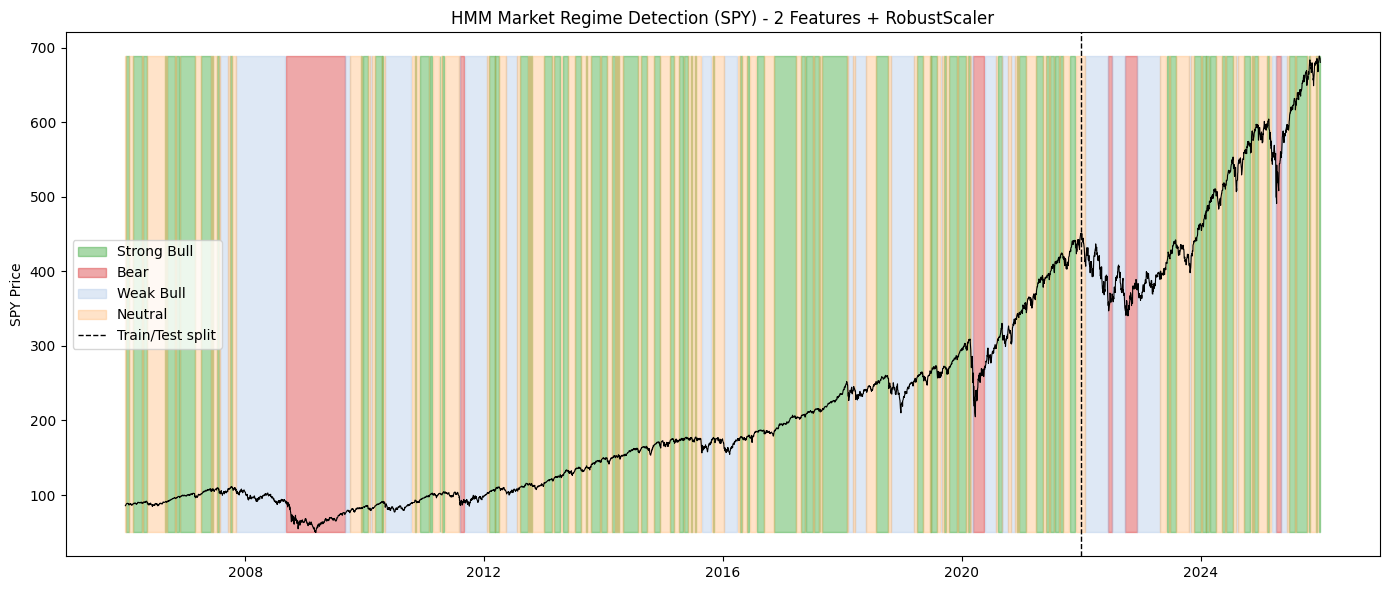

In [325]:
plt.figure(figsize=(14, 6))

plt.plot(features.index, close.loc[features.index], color='black', linewidth=0.8, zorder=3)

for state in range(4):
    mask = (states == state)
    plt.fill_between(features.index,
                     close.loc[features.index].min(),
                     close.loc[features.index].max(),
                     where=mask, alpha=0.4, color=colors[state],
                     label=state_labels[state], zorder=1)

split_date = features.index[split]
plt.axvline(split_date, color='black', linestyle='--', linewidth=1, label='Train/Test split')
plt.legend()
plt.title('HMM Market Regime Detection (SPY) - 2 Features + RobustScaler')
plt.ylabel('SPY Price')
plt.tight_layout()
plt.show()

In [326]:
for state in range(4):
    regime_returns = features['returns'].values[states == state]
    print(f"{state_labels[state]:8s} | Mean: {regime_returns.mean():.4f} | Std: {regime_returns.std():.4f} | Days: {len(regime_returns)}")

Strong Bull | Mean: 0.0013 | Std: 0.0046 | Days: 1805
Bear     | Mean: -0.0003 | Std: 0.0287 | Days: 413
Weak Bull | Mean: 0.0000 | Std: 0.0137 | Days: 1194
Neutral  | Mean: -0.0001 | Std: 0.0094 | Days: 1620


In [327]:
def compute_aic_bic(model, X):
    n_samples, n_features = X.shape
    n_states = model.n_components
    
    n_params = (
        n_states ** 2 +                 # transition matrix
        n_states * n_features +         # means
        n_states * n_features ** 2      # full covariance matrices
    )
    
    # model.score() returns total log-likelihood, no need to multiply
    log_likelihood = model.score(X)
    
    aic = 2 * n_params - 2 * log_likelihood
    bic = np.log(n_samples) * n_params - 2 * log_likelihood
    
    return aic, bic

In [328]:
result = []
all_scaled = scaler.transform(features)

for n in range(2, 7):
    m = GaussianHMM(n_components=n, covariance_type="full", 
                    n_iter=200, random_state=42)
    m.fit(scaled_train)
    
    aic, bic = compute_aic_bic(m, all_scaled)
    result.append((n, m.score(all_scaled), aic, bic, m.monitor_.converged))
    print(f"n={n} | Log-lik: {m.score(all_scaled):.2f} | AIC: {aic:.2f} | BIC: {bic:.2f} | Converged: {m.monitor_.converged}")

best_n = result[np.argmin([r[3] for r in result])][0]
print(f"\nBest number of states by BIC: {best_n}")

n=2 | Log-lik: -25682.73 | AIC: 51493.46 | BIC: 51910.97 | Converged: True
n=3 | Log-lik: -22130.54 | AIC: 44459.08 | BIC: 45104.91 | Converged: True
n=4 | Log-lik: -20167.76 | AIC: 40607.53 | BIC: 41494.73 | Converged: True
n=5 | Log-lik: -18956.88 | AIC: 38263.75 | BIC: 39405.38 | Converged: True
n=6 | Log-lik: -18306.98 | AIC: 37045.97 | BIC: 38455.06 | Converged: True

Best number of states by BIC: 6


In [329]:
results = []

for n in range(2, 7):
    m = GaussianHMM(n_components=n, covariance_type="full", n_iter=200, random_state=42)
    m.fit(scaled_train)
    
    aic = m.aic(all_scaled)
    bic = m.bic(all_scaled)
    results.append((n, aic, bic))
    print(f"n={n} | AIC: {aic:.2f} | BIC: {bic:.2f} | Converged: {m.monitor_.converged}")

n=2 | AIC: 51451.46 | BIC: 51731.98 | Converged: True
n=3 | AIC: 44397.08 | BIC: 44840.68 | Converged: True
n=4 | AIC: 40525.53 | BIC: 41145.27 | Converged: True
n=5 | AIC: 38161.75 | BIC: 38970.68 | Converged: True
n=6 | AIC: 36923.97 | BIC: 37935.12 | Converged: True


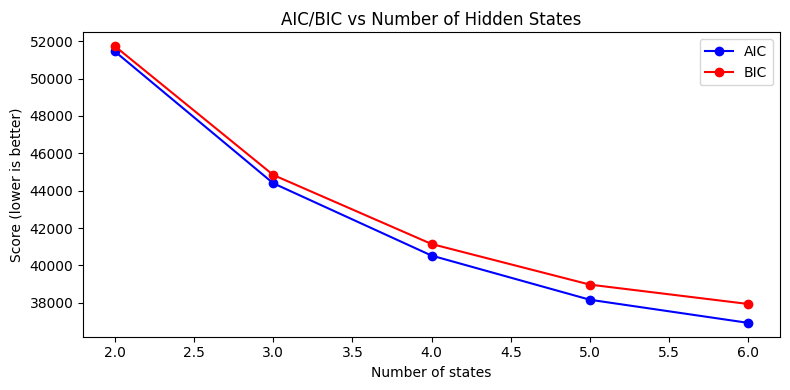

In [330]:
ns   = [r[0] for r in results]
aics = [r[1] for r in results]
bics = [r[2] for r in results]

plt.figure(figsize=(8, 4))
plt.plot(ns, aics, 'o-', label='AIC', color='blue')
plt.plot(ns, bics, 'o-', label='BIC', color='red')
plt.xlabel('Number of states')
plt.ylabel('Score (lower is better)')
plt.title('AIC/BIC vs Number of Hidden States')
plt.legend()
plt.tight_layout()
plt.show()

In [331]:
# Compare 3 vs 4 states directly
for n in [3, 4]:
    m = GaussianHMM(n_components=n, covariance_type="full", n_iter=200, random_state=42)
    m.fit(scaled_train)
    states_temp = m.predict(all_scaled)
    state_means_temp = [features['returns'].values[states_temp == s].mean() for s in range(n)]
    print(f"\nn={n} states:")
    print(f"Means: {sorted(state_means_temp)}")
    print(f"BIC: {m.bic(all_scaled):.2f}")


n=3 states:
Means: [np.float64(-0.00022775646630061137), np.float64(-0.00012209271662524086), np.float64(0.0011742945441017508)]
BIC: 44840.68

n=4 states:
Means: [np.float64(-0.0002646848160996546), np.float64(-0.00012068301657112472), np.float64(2.5694994253994702e-05), np.float64(0.0012963014202302863)]
BIC: 41145.27


In [332]:
# State persistence — average days spent in each regime before switching
def compute_persistence(states, state_labels):
    persistence = {label: [] for label in state_labels.values()}
    
    current_state = states[0]
    count = 1
    
    for i in range(1, len(states)):
        if states[i] == current_state:
            count += 1
        else:
            persistence[state_labels[current_state]].append(count)
            current_state = states[i]
            count = 1
    
    # Don't forget the last run
    persistence[state_labels[current_state]].append(count)
    
    print("State Persistence (avg consecutive days per regime):")
    for label, runs in persistence.items():
        print(f"{label:12s} | Avg: {np.mean(runs):.1f} days | Max: {np.max(runs)} days | Transitions: {len(runs)}")

compute_persistence(states, state_labels)

State Persistence (avg consecutive days per regime):
Bear         | Avg: 68.8 days | Max: 253 days | Transitions: 6
Neutral      | Avg: 15.3 days | Max: 77 days | Transitions: 106
Weak Bull    | Avg: 47.8 days | Max: 205 days | Transitions: 25
Strong Bull  | Avg: 20.7 days | Max: 104 days | Transitions: 87


In [333]:
#log-likelihood on train vs test set
scaled_test = scaler.transform(test_features)

train_score = model.score(scaled_train) / len(scaled_train)
test_score = model.score(scaled_test) / len(scaled_test)

print(f"Train log-likelihood (per sample): {train_score:.4f}")
print(f"Test log-likelihood (per sample): {test_score:.4f}")
print(f"Difference: {abs(train_score - test_score):.4f}")

if abs(train_score - test_score) < 0.5:
    print("\nModel generalizes well - train and test scores are close")
elif test_score < train_score - 0.5:
    print("\nPossible overfitting — test score is significantly lower than train")

Train log-likelihood (per sample): -3.9174
Test log-likelihood (per sample): -4.3695
Difference: 0.4521

Model generalizes well - train and test scores are close


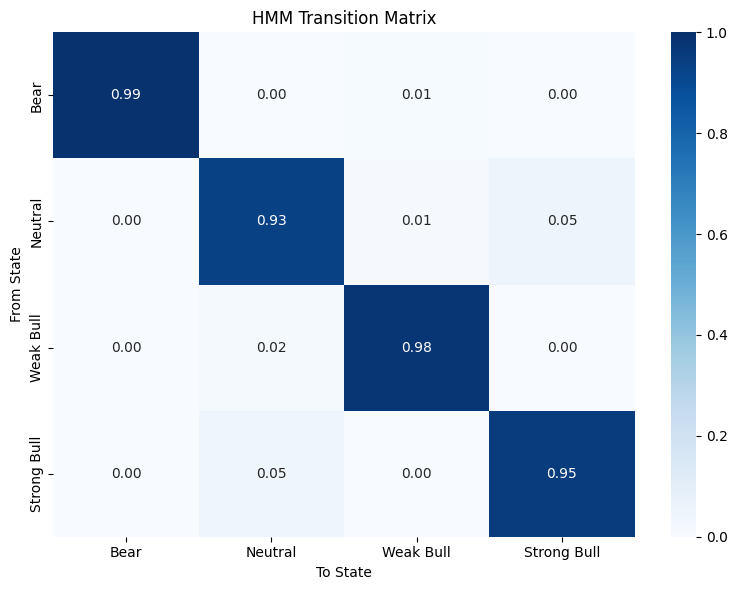

In [334]:
import seaborn as sns

# Get transition matrix and reorder by our state labels
# Build ordered label list from sorted_states
ordered_labels = [state_labels[sorted_states[i]] for i in range(4)]

# Reorder transition matrix rows/cols to match our labeling
transmat = model.transmat_

# Map sorted state indices to transition matrix
idx = [sorted_states[i] for i in range(4)]
reordered = transmat[np.ix_(idx, idx)]

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(reordered, 
            annot=True, 
            fmt='.2f',
            xticklabels=ordered_labels,
            yticklabels=ordered_labels,
            cmap='Blues',
            vmin=0, vmax=1)

plt.title('HMM Transition Matrix')
plt.ylabel('From State')
plt.xlabel('To State')
plt.tight_layout()
plt.show()

In [335]:
# Regime Prediction using forward algorithm + transition matrix
def predict_regime(model, recent_data, scaler, state_labels, sorted_states, k=1):
    # Scale the recent data
    scaled = scaler.transform(recent_data)

    # Forward algorithm - get current state probability distribution
    # model.predict_proba() returns P(state|observations) for each timestep
    state_probs = model.predict_proba(scaled)

    # Take the last timestep's probabilities as current state
    current_probs = state_probs[-1]

    # Project k steps ahead using the transition matrix
    future_probs = current_probs @ np.linalg.matrix_power(model.transmat_, k)

    #Map to labels
    predicted_state = np.argmax(future_probs)
    predicted_label = state_labels[predicted_state]

    print(f"Prediction {k} day(s) ahead:")
    print(f"Predicted regime: {predicted_label}")
    print(f"\nFull probability distribution:")
    for i in range(4):
        label = state_labels[sorted_states[i]]
        prob = future_probs[sorted_states[i]]
        print(f"  {label:.12s}: {prob:.4f} ({prob*100:.4f}%)")

    return predicted_label, future_probs

#Use last 60 days as recent data
recent_data = features.iloc[-60:]

#Predict 1, 5, 10 days ahead
for k in [1, 5, 10]:
    print(f"{'='*40}")
    predict_regime(model, recent_data, scaler, state_labels, sorted_states, k=k)
    print()

Prediction 1 day(s) ahead:
Predicted regime: Strong Bull

Full probability distribution:
  Bear: 0.0000 (0.0000%)
  Neutral: 0.0707 (7.0700%)
  Weak Bull: 0.0003 (0.0300%)
  Strong Bull: 0.9290 (92.9000%)

Prediction 5 day(s) ahead:
Predicted regime: Strong Bull

Full probability distribution:
  Bear: 0.0000 (0.0026%)
  Neutral: 0.2054 (20.5424%)
  Weak Bull: 0.0061 (0.6088%)
  Strong Bull: 0.7885 (78.8462%)

Prediction 10 day(s) ahead:
Predicted regime: Strong Bull

Full probability distribution:
  Bear: 0.0002 (0.0210%)
  Neutral: 0.3024 (30.2381%)
  Weak Bull: 0.0196 (1.9602%)
  Strong Bull: 0.6778 (67.7807%)



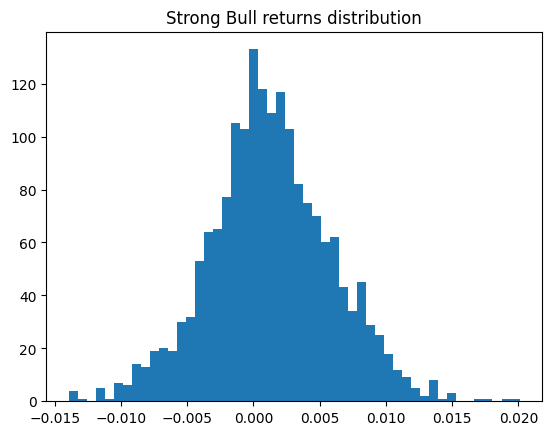

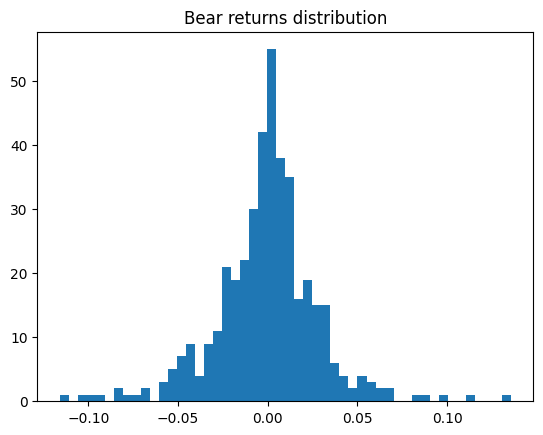

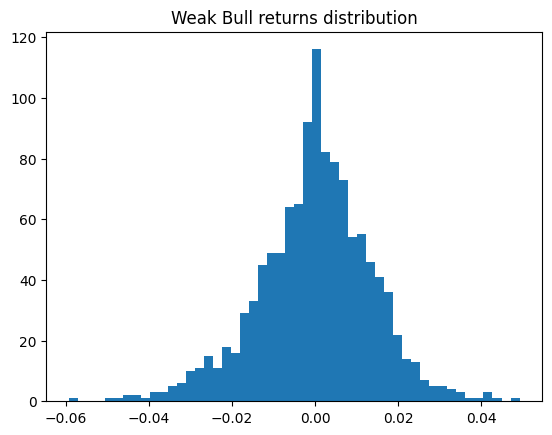

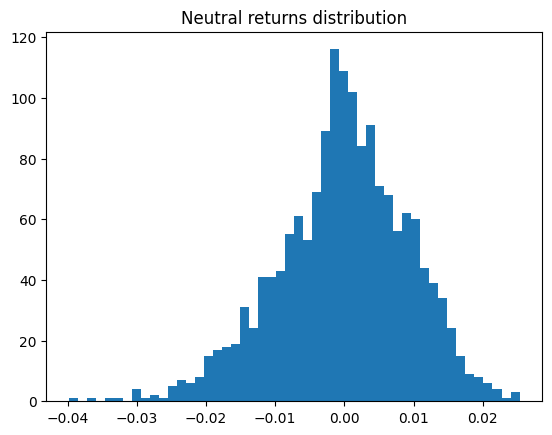

In [336]:
# Check if returns within each state look Gaussian
for state in range(4):
    regime_returns = features['returns'].values[states == state]
    plt.hist(regime_returns, bins=50)
    plt.title(f'{state_labels[state]} returns distribution')
    plt.show()